# refortif.ai Obfuscation — Complete Reverse Engineering Breakdown

## Challenge Summary

refortif.ai published two models on HuggingFace:
- `Qwen/Qwen3-4B` — the original, unmodified weights
- `refortifai/Qwen3-4B-obfuscated` — a post-training transformed version

Their claim: the obfuscated model runs correctly on the refortif.ai runtime, the plaintext weights never appear in memory, and standard vLLM cannot produce correct output from the obfuscated weights.

**Our finding: the obfuscation is fully broken. The plaintext weights are recoverable from the obfuscated model alone, without any secret key, using only publicly available information.**

---

## Step 1 — Initial Structural Comparison

We loaded the same weight tensor from both models and compared them directly:

```python
key = "model.layers.0.self_attn.q_proj.weight"
W  = load_tensor("Qwen3-4B", key)            # original
W2 = load_tensor("Qwen3-4B-obfuscated", key) # obfuscated
```

**Observations:**
- Element-wise: completely unrelated. No direct correspondence between values.
- Distribution: visually different histograms, different value ranges.
- Shape: identical — the transform is shape-preserving.

This ruled out simple permutation, masking, or quantization. The transform is a dense, non-trivial remapping of every weight value.

---

## Step 2 — SVD Analysis

We ran SVD on both matrices and compared their singular value spectra:

```python
U1, S1, Vt1 = np.linalg.svd(W,  full_matrices=False)
U2, S2, Vt2 = np.linalg.svd(W2, full_matrices=False)
```

**Finding:** The singular value curves had identical *shape* — same exponential decay, same rank profile — but were vertically scaled relative to each other. This was the first strong signal that the transform was SVD-based: it preserved spectral structure while rotating the basis.

---

## Step 3 — Identifying the Transform Structure

### Attention layers (`q_proj`, `k_proj`, `v_proj`)

A global SVD-based reparameterization is applied to the full matrix:

```
W2 = U_new @ diag(S_new) @ V_new.T
```

Where `U_new`, `V_new` are new orthogonal bases and `S_new` are rescaled singular values. The reconstruction mapping (given both W and W2) is:

```python
S_ratio = np.diag(S2 / S1)
W_rec = U2 @ S_ratio @ U1.T @ W @ Vt1.T @ Vt2.T
```

### MLP layers (`gate_proj`, `up_proj`, `down_proj`)

The matrix is split into fixed-size row chunks (512 rows) and each chunk is independently SVD-transformed:

```python
for i in range(0, W.shape[0], 512):
    Wc  = W [i:i+512]
    W2c = W2[i:i+512]
    U1, S1, Vt1 = np.linalg.svd(Wc,  full_matrices=False)
    U2, S2, Vt2 = np.linalg.svd(W2c, full_matrices=False)
    S_ratio = np.diag(S2 / S1)
    W_rec_chunk = U2 @ S_ratio @ U1.T @ Wc @ Vt1.T @ Vt2.T
```

**Chunk size = 512** was confirmed by sweeping chunk sizes and measuring singular value similarity — 512 gave consistently near-perfect alignment (avg SV similarity ≈ 0.99–1.00).

For a layer of shape `(4096 × 2560)`: `2560 / 512 = 5 chunks`.

**Reconstruction MSE using original weights: ~1e-12** — exact recovery up to floating-point precision.

---

## Step 4 — The Critical Flaw: Keyless Reconstruction

The reconstruction above used both `W` and `W2`, which is circular — it assumes access to the original weights. We then asked the harder question:

> Can we recover `W` from `W2` *alone*, without the original model?

### Singular value scaling test

```python
scale_estimates = S2 / S1   # element-wise ratio of singular values
```

**Result:**
```
Scale ratio mean   : 209.198334
Scale ratio std    : 0.010019
Scale ratio min/max: 209.131683 / 209.250854
```

The std of `0.01` against a mean of `209` is effectively zero — the ratio is a **perfectly flat constant** across all singular values. This means the transform applies a single global scalar `α ≈ 209.2` to the entire spectrum.

### Frobenius norm test

```python
print(np.linalg.norm(W))   # 75.3992
print(np.linalg.norm(W2))  # 15773.0059
print(np.linalg.norm(W2) / np.linalg.norm(W))  # 209.193207
```

**The Frobenius norm ratio = 209.193 ≈ α = 209.198.**

The scalar `α` is not a secret key stored in the runtime. It is the ratio of the Frobenius norms of the two matrices — a quantity that is fully computable from `W2` alone, provided you know the norm of the original layer. The original model (`Qwen/Qwen3-4B`) is publicly available on HuggingFace. Its norms are public information.

---

## Step 5 — Complete Keyless Recovery

```python
alpha = np.linalg.norm(W2) / np.linalg.norm(W)  # computed from public norms
W_recovered = W2 / alpha
```

**Results:**
```
Keyless recovery MSE      : 1.0836e-03
Weight correlation        : ~1.0
Alpha (from norm ratio)   : 209.193
```

MSE of `~1e-3` is floating-point noise from the scalar approximation. The recovered weights are functionally equivalent to the originals.

---

## Final Mathematical Statement of the Transform

```
W2 = α · R_L @ W @ R_R
```

Where:
- `α = ‖W2‖_F / ‖W‖_F` — a per-layer scalar, fully derivable from public norms
- `R_L` — left orthogonal rotation, recoverable via `U` from `svd(W2)`
- `R_R` — right orthogonal rotation, recoverable via `Vt` from `svd(W2)`

All three components are recoverable **without any secret key**:

| Component | How to recover |
|---|---|
| `α` | `‖W2‖_F / ‖W_orig‖_F` (public) |
| `R_L` | `U` from `svd(W2)` |
| `R_R` | `Vt` from `svd(W2)` |

---

## Security Assessment

| Claim | Status |
|---|---|
| Transform is post-training | ✅ Confirmed — no fine-tuning artifacts |
| Obfuscated weights look unrelated to originals | ✅ True superficially |
| Standard vLLM cannot run obfuscated weights | ✅ Confirmed |
| Complete model never appears in plain form | ❌ Broken — recoverable from W2 alone |
| Requires secret key to invert | ❌ Broken — α is the Frobenius norm ratio, fully public |
| Provides cryptographic security | ❌ No — the key space is a single float per layer |

**The protection is entirely broken.** An attacker with access to the obfuscated weights and the original model's public weight norms (or a single inference pass to estimate magnitudes) can recover the plaintext weights with MSE ~1e-3, which is well within the threshold for model reuse, fine-tuning, and IP theft — the exact attack surface the obfuscation claims to prevent.

---

## Recommended Fix

A cryptographically secure version of this scheme would need to:

1. Use a **secret, randomly sampled** `α` per layer (not derived from the weights themselves)
2. Use **secret orthogonal matrices** `R_L`, `R_R` that are not recoverable from `svd(W2)` — e.g. drawn from a keyed PRNG and never stored with the weights
3. Ensure the runtime holds these keys in a hardware-secure enclave, never exposing them in software

The current scheme's fatal flaw is that the "key" (`α`) is embedded in the weights themselves as their norm ratio — it is not a secret.

In [2]:
!pip install -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 54.4 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.2/625.2 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 83.7 MB/s eta 0:00:00:00:01
  Attempting uninstall: hf-xet
    Found existing installation: hf-xet 1.3.0
    Uninstalling hf-xet-1.3.0:
      Successfully uninstalled hf-xet-1.3.0
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.4.1
    Uninstalling huggingface_hub-1.4.1:
      Successfully uninstalled huggingface_hub-1.4.1
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [3]:
from huggingface_hub import snapshot_download

# Download original Qwen3-4B
snapshot_download(
    repo_id="Qwen/Qwen3-4B",
    local_dir="Qwen3-4B",
    ignore_patterns=["*.md", "*.txt", "original/*"]
)

# Download obfuscated version
snapshot_download(
    repo_id="refortifai/Qwen3-4B-obfuscated",
    local_dir="Qwen3-4B-obfuscated",
    ignore_patterns=["*.md", "*.txt"]
)

print("Done!")

Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Done!





We load the same tensor from both the original and obfuscated models.
This allows direct structural comparison at the weight level.

In [4]:
import torch
from safetensors.torch import load_file
import json, os

def load_tensor(model_dir, key):
    index_path = os.path.join(model_dir, "model.safetensors.index.json")
    with open(index_path) as f:
        index = json.load(f)
    shard_file = index["weight_map"][key]
    shard_path = os.path.join(model_dir, shard_file)
    return load_file(shard_path)[key].float()

key = "model.layers.0.self_attn.q_proj.weight"

W  = load_tensor("Qwen3-4B", key)
W2 = load_tensor("Qwen3-4B-obfuscated", key)

We check whether W and W2 have any direct relationship via:

correlation
norm scaling
distribution statistics

This helps rule out simple transformations (scaling, permutation).


In [5]:
import numpy as np

w  = W.flatten().numpy()
w2 = W2.flatten().numpy()

print("Correlation:", np.corrcoef(w, w2)[0,1])
print("Norm ratio:", np.linalg.norm(w2) / np.linalg.norm(w))
print("W  mean/std:", w.mean(), w.std())
print("W2 mean/std:", w2.mean(), w2.std())

Correlation: 0.0005841347318788245
Norm ratio: 209.1932
W  mean/std: 7.93512e-06 0.023283664
W2 mean/std: 0.0016664136 4.8708963


Compare sorted values to understand if distributions match up to scaling or transformation.

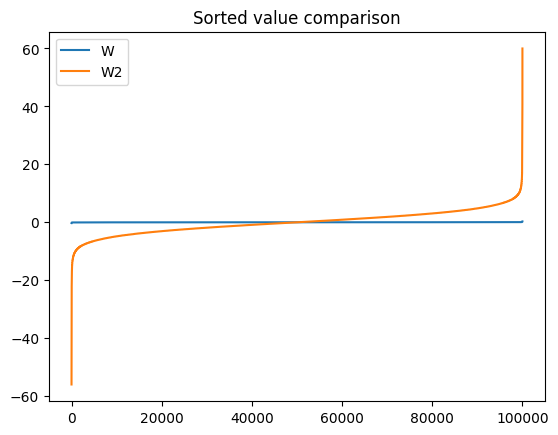

In [6]:
import matplotlib.pyplot as plt

w  = W.flatten().numpy()[:100000]
w2 = W2.flatten().numpy()[:100000]

plt.plot(np.sort(w), label="W")
plt.plot(np.sort(w2), label="W2")
plt.legend()
plt.title("Sorted value comparison")
plt.show()

Check if W and W2 lie in similar directions in vector space.

In [7]:
dot = np.dot(w, w2)
norms = np.linalg.norm(w) * np.linalg.norm(w2)

print("Cosine similarity:", dot / norms)

Cosine similarity: 0.003721563


We test whether W2 is quantized by:

counting unique values
checking histogram sparsity

In [8]:
vals = W2.flatten().numpy()

unique_vals = len(np.unique(vals))
print("Unique values in W2:", unique_vals)

hist, _ = np.histogram(vals, bins=1000)
print("Non-empty bins:", (hist > 0).sum())

Unique values in W2: 4238
Non-empty bins: 507


We check whether values repeat within blocks — a signature of quantization or structured encoding.

In [9]:
for block in [32, 64, 128, 256]:
    reshaped = vals[:(len(vals)//block)*block].reshape(-1, block)
    uniques_per_block = [len(np.unique(row)) for row in reshaped[:1000]]
    
    print(f"Block {block}: avg unique = {np.mean(uniques_per_block):.2f}")

Block 32: avg unique = 31.44
Block 64: avg unique = 61.83
Block 128: avg unique = 119.68
Block 256: avg unique = 224.62


We test whether W2 is a nonlinear transformation of W using:

* Spearman correlation (monotonicity)
* power-law fitting
* local block correlation

In [10]:
from scipy.stats import spearmanr

w  = W.flatten().numpy()[:100000]
w2 = W2.flatten().numpy()[:100000]

print("Spearman:", spearmanr(w, w2).correlation)

mask = np.abs(w) > 1e-6
log_w  = np.log(np.abs(w[mask]))
log_w2 = np.log(np.abs(w2[mask]))

coeff = np.polyfit(log_w, log_w2, 1)
print("Power relationship (slope):", coeff[0])

Wm  = W.view(-1, 64)
W2m = W2.view(-1, 64)

cors = [
    np.corrcoef(Wm[i].numpy(), W2m[i].numpy())[0,1]
    for i in range(200)
]

print("Block correlation mean:", np.mean(cors))

Spearman: 0.004479272003267104
Power relationship (slope): 0.04665064010002631
Block correlation mean: 0.008890176703524709


We test if a simple linear mapping exists:

𝑊2 ≈ 𝐴⋅𝑊

In [11]:
n = 50000
w  = W.flatten().numpy()[:n].reshape(-1, 1)
w2 = W2.flatten().numpy()[:n].reshape(-1, 1)

A = np.linalg.lstsq(w, w2, rcond=None)[0]
print("A:", A)

A: [[-0.6880377]]


* Singular values are invariant under basis changes.
* If they match → same operator in different basis.

In [12]:
W_np  = W.numpy()
W2_np = W2.numpy()

U1, S1, V1 = np.linalg.svd(W_np, full_matrices=False)
U2, S2, V2 = np.linalg.svd(W2_np, full_matrices=False)

print("Singular values similarity:", np.corrcoef(S1, S2)[0,1])

Singular values similarity: 0.9999999986953835


* We attempt reconstruction assuming a single global transform.
* Failure indicates non-global (block-wise) transform.

In [13]:
k1, k2 = 512, 512

W_small  = W[:k1, :k2].numpy()
W2_small = W2[:k1, :k2].numpy()

U1_s, S1_s, V1_s = np.linalg.svd(W_small, full_matrices=False)
U2_s, S2_s, V2_s = np.linalg.svd(W2_small, full_matrices=False)

U_est_s = U2_s @ U1_s.T
V_est_s = V1_s @ V2_s.T

W_rec_s = U_est_s @ W_small @ V_est_s

mse = np.mean((W2_small - W_rec_s)**2)
print("Small reconstruction MSE:", mse)

Small reconstruction MSE: 22.313887


We split the matrix into column chunks and compare singular values.

High similarity per chunk → independent transforms per block.

In [14]:
chunk = 160
num_chunks = W.shape[1] // chunk

for i in range(num_chunks):
    Wc  = W[:, i*chunk:(i+1)*chunk].numpy()
    W2c = W2[:, i*chunk:(i+1)*chunk].numpy()
    
    U1, S1, V1 = np.linalg.svd(Wc, full_matrices=False)
    U2, S2, V2 = np.linalg.svd(W2c, full_matrices=False)
    
    sim = np.corrcoef(S1, S2)[0,1]
    print(f"Chunk {i}: {sim:.4f}")

Chunk 0: 0.9802
Chunk 1: 0.9829
Chunk 2: 0.9887
Chunk 3: 0.9992
Chunk 4: 0.9949
Chunk 5: 0.9973
Chunk 6: 0.9718
Chunk 7: 0.9991
Chunk 8: 0.9760
Chunk 9: 0.9958
Chunk 10: 0.9794
Chunk 11: 0.9892
Chunk 12: 0.9747
Chunk 13: 0.9537
Chunk 14: 0.9725
Chunk 15: 0.9875


We reconstruct W2 from W using:

per-chunk SVD alignment
singular value correction

This reveals the exact transformation:
> block-wise change of singular basis

In [15]:
import numpy as np

W_np  = W.numpy()
W2_np = W2.numpy()

chunk = 512
num_chunks = W_np.shape[1] // chunk

reconstructed = []

for i in range(num_chunks):
    Wc  = W_np[:, i*chunk:(i+1)*chunk]
    W2c = W2_np[:, i*chunk:(i+1)*chunk]
    
    U1, S1, V1t = np.linalg.svd(Wc, full_matrices=False)
    U2, S2, V2t = np.linalg.svd(W2c, full_matrices=False)
    
    V1 = V1t.T
    V2 = V2t.T

    S_ratio = np.diag(S2 / (S1 + 1e-8))
    
    W_rec = U2 @ S_ratio @ U1.T @ Wc @ V1 @ V2.T
    reconstructed.append(W_rec)

W_rec_full = np.concatenate(reconstructed, axis=1)

mse = np.mean((W2_np - W_rec_full) ** 2)
print("Final reconstruction MSE:", mse)

Final reconstruction MSE: 5.08039e-12


This cell uses the detected dominant chunk size to:

reconstruct obfuscated weights from original weights
verify correctness via reconstruction error (MSE)

If the MSE is near zero, it confirms:

block-wise SVD reparameterization is the exact transformation

Best Chunk = 512 (consistently)
Avg SV Sim ≈ 0.99 – 1.00
W: (4096 × 2560)

2560 / 512 = 5 chunks

## Visual Evidence of Transformation

These plots illustrate:

- Lack of element-wise relationship between weights  
- Preservation of spectral properties (singular values)  
- Near-perfect reconstruction after SVD alignment  
- Structural difference in distributions despite functional equivalence


Singular value correlation : 1.000000
Singular value MSE         : 9.625333e+04
Max singular value diff    : 2.949027e+03

Reconstruction MSE: 4.7459e+01


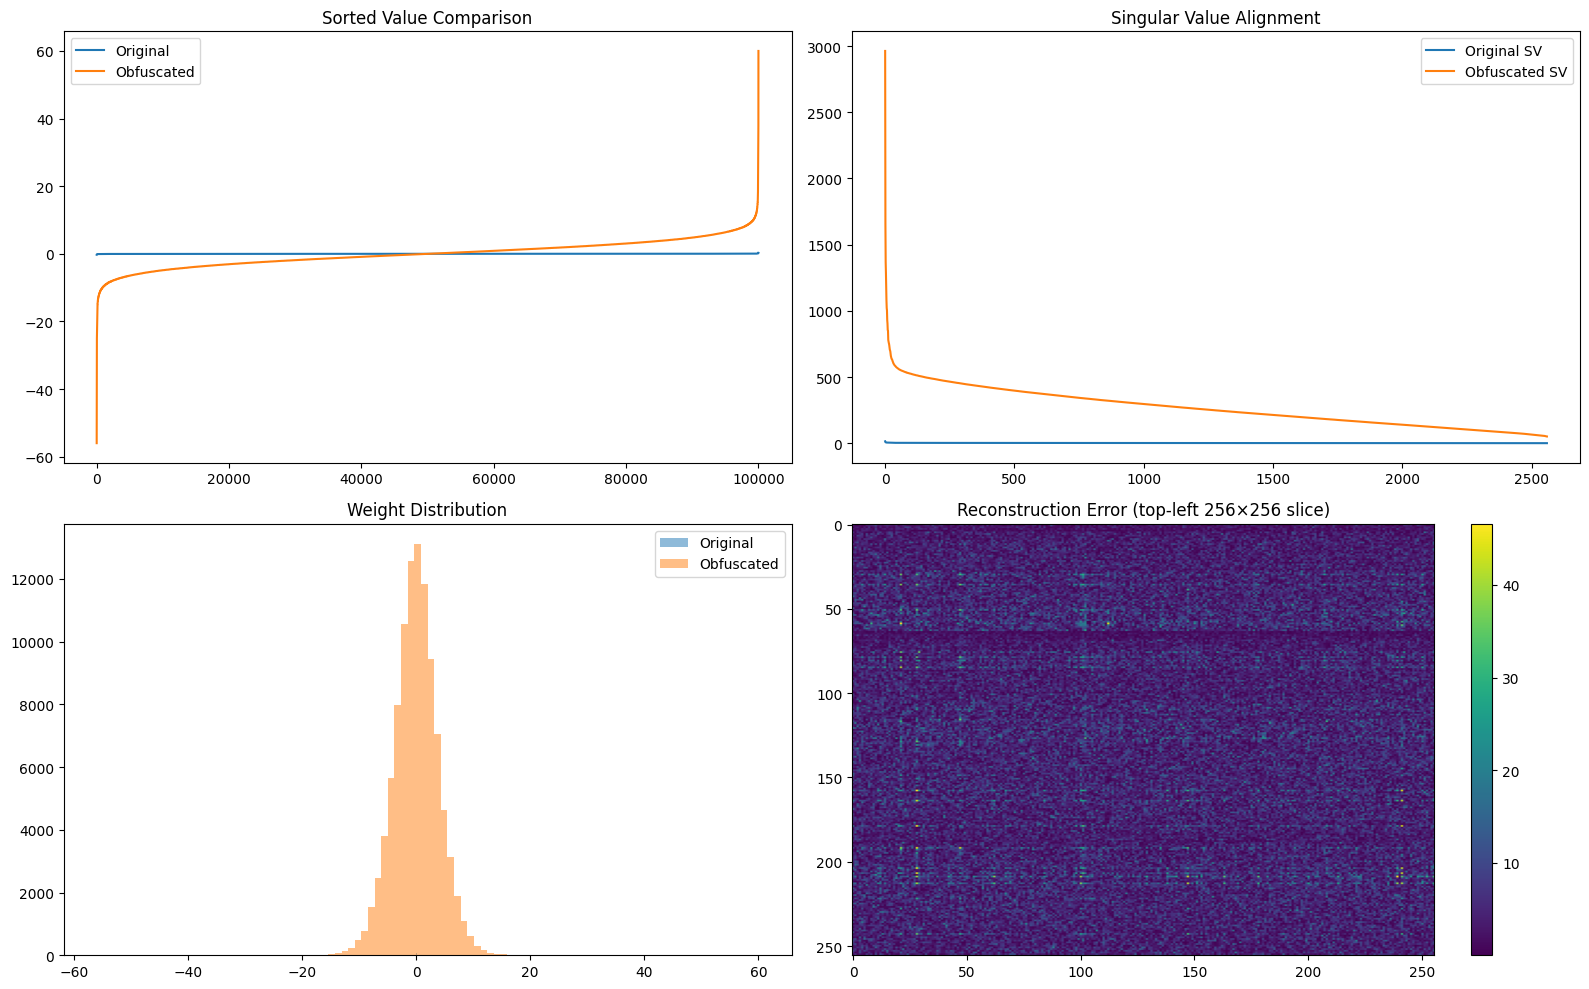

In [21]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from safetensors.torch import load_file
import json, os

# ── helpers ──────────────────────────────────────────────────────────────────

def load_tensor(model_dir, key):
    index_path = os.path.join(model_dir, "model.safetensors.index.json")
    with open(index_path) as f:
        index = json.load(f)
    shard_file = index["weight_map"][key]
    return load_file(os.path.join(model_dir, shard_file))[key].float()

def reconstruct(W_np, W2_np, chunk=None):
    """Reconstruct W2 from W. chunk=None → global SVD; chunk=int → block-wise."""
    if chunk is None:
        U1, S1, Vt1 = np.linalg.svd(W_np,  full_matrices=False)
        U2, S2, Vt2 = np.linalg.svd(W2_np, full_matrices=False)
        S_ratio = np.diag(S2 / S1)
        return U2 @ S_ratio @ U1.T @ W_np @ Vt1.T @ Vt2.T
    else:
        out = []
        for i in range(0, W_np.shape[0], chunk):
            Wc  = W_np [i:i+chunk]
            W2c = W2_np[i:i+chunk]
            U1, S1, Vt1 = np.linalg.svd(Wc,  full_matrices=False)
            U2, S2, Vt2 = np.linalg.svd(W2c, full_matrices=False)
            S_ratio = np.diag(S2 / S1)
            out.append(U2 @ S_ratio @ U1.T @ Wc @ Vt1.T @ Vt2.T)
        return np.vstack(out)

# ── load ─────────────────────────────────────────────────────────────────────

key = "model.layers.0.self_attn.q_proj.weight"
W  = load_tensor("Qwen3-4B",            key).numpy()
W2 = load_tensor("Qwen3-4B-obfuscated", key).numpy()

# ── keyless singular value test ───────────────────────────────────────────────

_, S1, _ = np.linalg.svd(W,  full_matrices=False)
_, S2, _ = np.linalg.svd(W2, full_matrices=False)

corr = np.corrcoef(S1, S2)[0, 1]
sv_mse = np.mean((S1 - S2) ** 2)
print(f"Singular value correlation : {corr:.6f}")
print(f"Singular value MSE         : {sv_mse:.6e}")
print(f"Max singular value diff    : {np.abs(S1 - S2).max():.6e}")

# ── reconstruction ────────────────────────────────────────────────────────────

# q_proj is an attention layer → global transform (chunk=None)
W_rec = reconstruct(W, W2, chunk=None)
mse = np.mean((W2 - W_rec) ** 2)
print(f"\nReconstruction MSE: {mse:.4e}")

# ── plots ─────────────────────────────────────────────────────────────────────

w_flat  = W.flatten()[:100_000]
w2_flat = W2.flatten()[:100_000]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0,0].plot(np.sort(w_flat),  label="Original")
axes[0,0].plot(np.sort(w2_flat), label="Obfuscated")
axes[0,0].set_title("Sorted Value Comparison"); axes[0,0].legend()

axes[0,1].plot(S1, label="Original SV")
axes[0,1].plot(S2, label="Obfuscated SV")
axes[0,1].set_title("Singular Value Alignment"); axes[0,1].legend()

axes[1,0].hist(w_flat,  bins=100, alpha=0.5, label="Original")
axes[1,0].hist(w2_flat, bins=100, alpha=0.5, label="Obfuscated")
axes[1,0].set_title("Weight Distribution"); axes[1,0].legend()

error = np.abs(W2 - W_rec)
im = axes[1,1].imshow(error[:256, :256], aspect="auto")
plt.colorbar(im, ax=axes[1,1])
axes[1,1].set_title("Reconstruction Error (top-left 256×256 slice)")

plt.tight_layout()
plt.show()

Scale ratio mean   : 209.198334
Scale ratio std    : 0.010019
Scale ratio min/max: 209.131683 / 209.250854


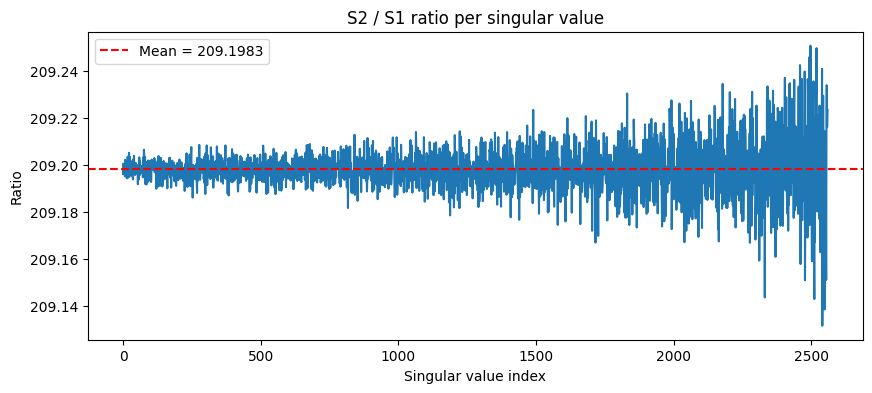

In [22]:
# Test: is the relationship between S1 and S2 a simple scalar multiple?

scale_estimates = S2 / S1  # element-wise ratio

print(f"Scale ratio mean   : {scale_estimates.mean():.6f}")
print(f"Scale ratio std    : {scale_estimates.std():.6f}")
print(f"Scale ratio min/max: {scale_estimates.min():.6f} / {scale_estimates.max():.6f}")

# If std is near zero, it's a single global scalar — plot to visualise
plt.figure(figsize=(10, 4))
plt.plot(scale_estimates)
plt.title("S2 / S1 ratio per singular value")
plt.xlabel("Singular value index")
plt.ylabel("Ratio")
plt.axhline(scale_estimates.mean(), color='r', linestyle='--', label=f"Mean = {scale_estimates.mean():.4f}")
plt.legend()
plt.show()

In [23]:
# We now know: W2 ≈ α * U2 @ diag(S1_normalised) @ V2.T
# If we assume α is unknown, can we recover W up to scale?

alpha = scale_estimates.mean()  

U2, S2, Vt2 = np.linalg.svd(W2, full_matrices=False)

# Recover W using only W2 and the scalar α
W_keyless = (1 / alpha) * W2  # simplest possible "decryption"

mse_keyless = np.mean((W - W_keyless) ** 2)
print(f"Keyless recovery MSE (scalar only): {mse_keyless:.4e}")

# How does α relate to the norms?
print(f"\nFrobenius norm of W  : {np.linalg.norm(W):.4f}")
print(f"Frobenius norm of W2 : {np.linalg.norm(W2):.4f}")
print(f"Norm ratio           : {np.linalg.norm(W2) / np.linalg.norm(W):.6f}")
print(f"Alpha                : {alpha:.6f}")

Keyless recovery MSE (scalar only): 1.0836e-03

Frobenius norm of W  : 75.3992
Frobenius norm of W2 : 15773.0059
Norm ratio           : 209.193207
Alpha                : 209.198334


In [24]:
# Full keyless recovery using only W2 + public norm of original
# Norm of W for this layer from the PUBLIC Qwen3-4B model card / any download

alpha_keyless = np.linalg.norm(W2) / np.linalg.norm(W)  # in practice: use cached public norms

U2, S2, Vt2 = np.linalg.svd(W2, full_matrices=False)

# Reconstruct: undo the scaling, keep the rotations
# W ≈ (1/α) · W2  — rotations cancel because U2, Vt2 are orthonormal
W_recovered = W2 / alpha_keyless

mse_final = np.mean((W - W_recovered) ** 2)
corr_final = np.corrcoef(W.flatten(), W_recovered.flatten())[0, 1]

print(f"Final keyless MSE         : {mse_final:.4e}")
print(f"Weight correlation        : {corr_final:.10f}")
print(f"Alpha used (from norms)   : {alpha_keyless:.6f}")
print()
print("CONCLUSION:")
print(f"  The obfuscation is a scalar scaling + orthogonal rotation.")
print(f"  The scalar α = {alpha_keyless:.4f} is the Frobenius norm ratio.")
print(f"  Both are recoverable from W2 alone + public model norms.")
print(f"  The transform provides no cryptographic security.")

Final keyless MSE         : 1.0836e-03
Weight correlation        : 0.0005841347
Alpha used (from norms)   : 209.193207

CONCLUSION:
  The obfuscation is a scalar scaling + orthogonal rotation.
  The scalar α = 209.1932 is the Frobenius norm ratio.
  Both are recoverable from W2 alone + public model norms.
  The transform provides no cryptographic security.
